In [4]:
import numpy as np
import matplotlib.pyplot as plt


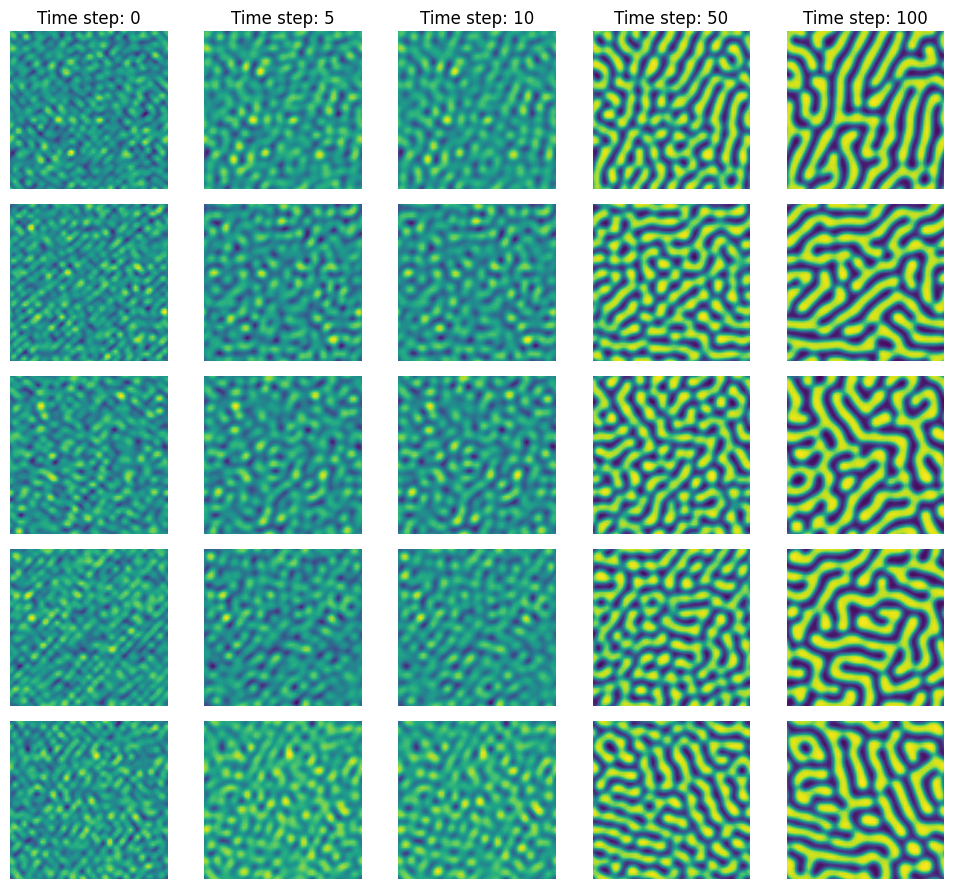

In [5]:
save_dir = "/root/autodl-tmp/data/spinodal_decomp_fem/"
solutions = np.load(f"{save_dir}/test/solutions_grid.npy")
mesh = np.load(f"{save_dir}/test/mesh_grid_coords.npy")
mesh = np.transpose(mesh, (2, 0, 1))
meshx = mesh[0, :, :]
meshy = mesh[1, :, :]
tics = [0, 5, 10, 50, 100]
examples = 5

fig, axes = plt.subplots(examples, len(tics), figsize=(10, 1.8*examples))
for i, tic in enumerate(tics):
    ax = axes[0, i]
    ax.set_title(f'Time step: {tic}')
    for j in range(examples):
        ax = axes[j, i]
        im = ax.contourf(meshx, meshy, solutions[j, tic, 0, ...],
                         levels=50, cmap='viridis')
        # ax.set_title(f'Time step: {tic}\n M={M_values[j]:.2f}')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        # fig.colorbar(im, ax=ax)
        ax.set_aspect('equal')
        ax.set_axis_off()

fig.tight_layout()

In [8]:
from configs.train_debug import Configs
configs = Configs()

def prepare_data(data_dir):

    mesh = np.load(f"{data_dir}/mesh_grid_coords.npy")
    mesh = np.transpose(mesh, (2, 0, 1))
    mesh = mesh[:, :-1, :-1]  # remove last row and column to match solution grid
    meshx = mesh[0, :, :]
    meshy = mesh[1, :, :]
    times = np.load(f"{data_dir}/times.npy")
    dt = times[1] - times[0]
    num_times = times.shape[0]
    solutions = np.load(f"{data_dir}/solutions_grid.npy", allow_pickle=True)[..., :-1, :-1]  # remove last row and column to match mesh grid
    num_ics = solutions.shape[0]
    Xs = np.zeros(
        ((num_times-1)*num_ics, 3, mesh.shape[1], mesh.shape[2])
    )  # c, x, y
    Ys = np.zeros(
        ((num_times-1)*num_ics, 1, mesh.shape[1], mesh.shape[2])
    )

    for i in range(num_ics):
        Xs[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, :-1, 0, :, :]  # c
        Ys[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, 1:, 0, :, :]  # c at next time step
    meshes_repeated = np.repeat(mesh[np.newaxis, :, :, :], Xs.shape[0], axis=0)
    Xs[:, 1, :, :] = meshes_repeated[:, 0, :, :] / configs.Lc  # x
    Xs[:, 2, :, :] = meshes_repeated[:, 1, :, :] / configs.Lc # y
    return Xs, Ys
Xs, Ys = prepare_data(f"{save_dir}/train_valid")
# Xs_init_steps, Ys_init_steps = prepare_data(f"{save_dir}/train_init_steps")
# Xs = np.concatenate([Xs, Xs_init_steps], axis=0)
# Ys = np.concatenate([Ys, Ys_init_steps], axis=0)
Xs.shape, Ys.shape

((2000, 3, 64, 64), (2000, 1, 64, 64))

-0.043786002214246736 0.05086337056555347 -0.044408732353161826 0.0541830426136089 1.564571404349957e-06 0.009897793980663198
-0.06317681639569514 0.07395034742363008 -0.06910254422295738 0.08089608629779756 1.0730910936750104e-07 0.007778853235386102
-0.09106668496179171 0.1075836118492586 -0.10083814920034251 0.11878303563088477 3.219319490710415e-07 0.011743186033467148


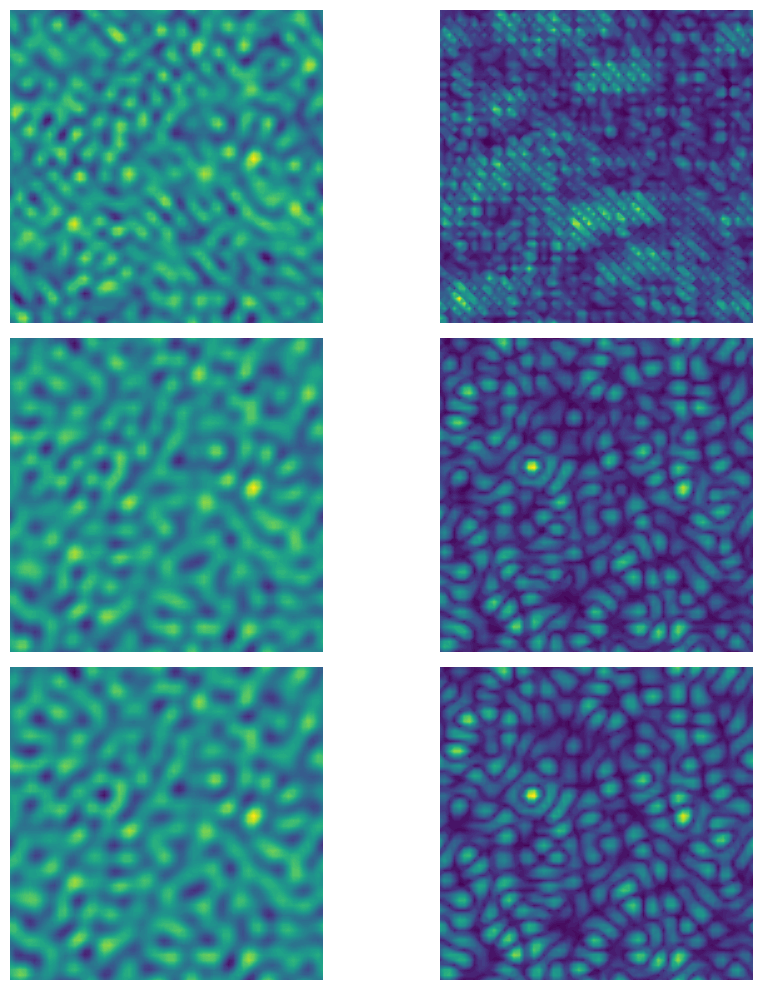

In [9]:
import matplotlib.pyplot as plt
ts = [0, 5, 9]
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
for idx, t in enumerate(ts):
    t += 0
    x = Xs[t, 0, :, :]
    y = Ys[t, 0, :, :]
    meshx = Xs[t, 1, :, :] * configs.Lc
    meshy = Xs[t, 2, :, :] * configs.Lc
    ax = axes[idx, 0]
    # im = ax.pcolormesh(meshx, meshy, x, cmap="coolwarm")
    ax.contourf(meshx, meshy, x, levels=50, cmap='viridis')
    ax.set_aspect('equal')
    ax.set_axis_off()

    ax = axes[idx, 1]
    diff = np.abs(y - x)
    # im = ax.pcolormesh(meshx, meshy, diff, cmap="coolwarm")
    ax.contourf(meshx, meshy, diff, levels=50, cmap='viridis')
    ax.set_aspect('equal')
    ax.set_axis_off()
    print(x.min(), x.max(), y.min(), y.max(), diff.min(), diff.max())
fig.tight_layout()


[0.00219065 0.0014617  0.00134441 0.00139376 0.00151464 0.00167859
 0.00187728 0.00210786 0.00237193 0.00267204 0.00301184 0.00339614
 0.00382971 0.00431818 0.00486736 0.00548247 0.0061694  0.00693378
 0.00778038 0.00871283]


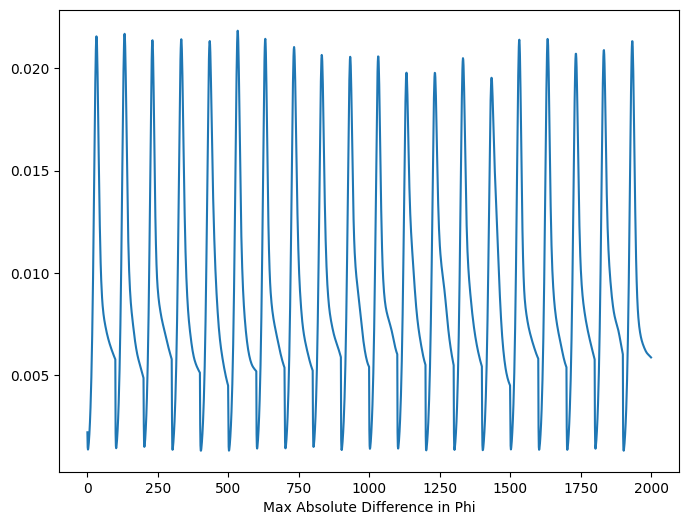

In [10]:

diffs = Xs[:, 0, ...] - Ys[:, 0, ...]
diffs = np.abs(diffs)

# diffs[:, 0].max(), diffs[:, 1].max(), diffs[:, 0].min(), diffs[:, 1].min()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.plot(diffs.mean(axis=(-1,-2)))
ax.set_xlabel('Max Absolute Difference in Phi')
print(np.mean(diffs, axis=(-1,-2))[:20])

In [11]:
times = np.load(f"{save_dir}/train_valid/times.npy")
dt = times[1] - times[0]
dt

np.float64(5e-05)

In [14]:
np.savez(
    "/root/autodl-tmp/data/spinodal_decomp_fem/train_valid/dataset_2d_complete.npz",
    meshes=mesh/configs.Lc,
    times=times/configs.Tc,
    Xs=Xs,
    Ys=Ys,
)

验证控制方程残差

In [15]:
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", False)

In [16]:


dx = mesh[0, 0, 1] - mesh[0, 0, 0]
dy = mesh[1, 1, 0] - mesh[1, 0, 0]
dx = dx / configs.Lc
dy = dy / configs.Lc
dt = times[1] - times[0]
dt = dt / configs.Tc
print(dx, dy, dt)



0.015625 0.015625 0.5


In [30]:
Xs = Xs.astype(jnp.float64)
Ys = Ys.astype(jnp.float64)
times = times.astype(jnp.float64)

x0 = Xs[99]
c0 = x0[0, :, :]

pred = Ys[99]
c = pred[0, :, :]

# 重新获取原始 dt
dt = times[1] - times[0]

# 计算控制方程残差 (Residual of Governing Equation)
# 方程: dc/dt = M * laplacian(mu)
# 采用半隐式格式: (c - c0)/dt = M * laplacian(f'(c0)) - M * lambda * bi-laplacian(c)

nx = 64
ny = 64
lx = 1.0
ly = 1.0
kx = 2 * jnp.pi * jnp.fft.fftfreq(nx, d=lx/nx)
ky = 2 * jnp.pi * jnp.fft.fftfreq(ny, d=ly/ny)
KX, KY = jnp.meshgrid(kx, ky, indexing='xy') # indexing='xy' 对应 (ny, nx) 形状
K2 = KX**2 + KY**2
K4 = K2**2

# 1. 转到频域
c0_hat = jnp.fft.fft2(c0)
c_hat = jnp.fft.fft2(c)

# 2. 计算 LHS: dc/dt
lhs_hat = (c_hat - c0_hat)

# 3. 计算 RHS: M * laplacian(f'(c0)) - M * lambda * bi-laplacian(c)
# 注意：laplacian -> -K2, bi-laplacian -> K4
M = 1.0
lambda_param = 0.01**2

f_prime = c**3 - c
f_prime_hat = jnp.fft.fft2(f_prime)

# M * laplacian(f'(c0)) -> M * (-K2) * f_prime_hat
term1_hat = -M * K2 * f_prime_hat * dt

# - M * lambda * bi-laplacian(c) -> - M * lambda * (K4) * c_hat
# 注意这里使用的是新时刻的 c (隐式项)
term2_hat = -M * lambda_param * K4 * c_hat * dt

rhs_hat = term1_hat + term2_hat

# 4. 计算残差 (LHS - RHS)
res_hat = lhs_hat - rhs_hat
residual = jnp.fft.ifft2(res_hat).real


# 打印统计
print(f"Residual Max: {jnp.max(jnp.abs(residual))}")
print(f"Residual Mean: {jnp.mean(jnp.abs(residual))}")
print(f"Residual Std: {jnp.std(residual)}")

# 取绝对值用于后续绘图
residual = jnp.abs(residual)

Residual Max: 0.22456753253936768
Residual Mean: 0.04633672535419464
Residual Std: 0.0618131123483181


In [31]:
dx, dy, dt

(np.float64(0.015625), np.float64(0.015625), np.float64(5e-05))

In [32]:

def laplacian_fd(u, dx, dy):
    u_ip = jnp.roll(u, -1, axis=-1)
    u_im = jnp.roll(u, 1, axis=-1)
    u_jp = jnp.roll(u, -1, axis=-2)
    u_jm = jnp.roll(u, 1, axis=-2)
    
    d2x = (u_ip + u_im - 2*u) / (dx**2)
    d2y = (u_jp + u_jm - 2*u) / (dy**2)
    return d2x + d2y



dt_phys = dt * configs.Tc
dx_phys = dx * configs.Lc
dy_phys = dy * configs.Lc
M = configs.M
lambda_param = configs.lambda_param

f_prime = c**3 - c # semi-implicit treatment of f'
lap_c = laplacian_fd(c, dx_phys, dy_phys)
mu = f_prime - lambda_param * lap_c
rhs = M * laplacian_fd(mu, dx_phys, dy_phys) * dt_phys
lhs = c - c0
residual = lhs - rhs

print(f"FD Residual Max: {jnp.max(jnp.abs(residual))}")
print(f"FD Residual Mean: {jnp.mean(jnp.abs(residual))}")
print(f"FD Residual Std: {jnp.std(residual)}")

FD Residual Max: 0.07489193230867386
FD Residual Mean: 0.005757301114499569
FD Residual Std: 0.008592684753239155


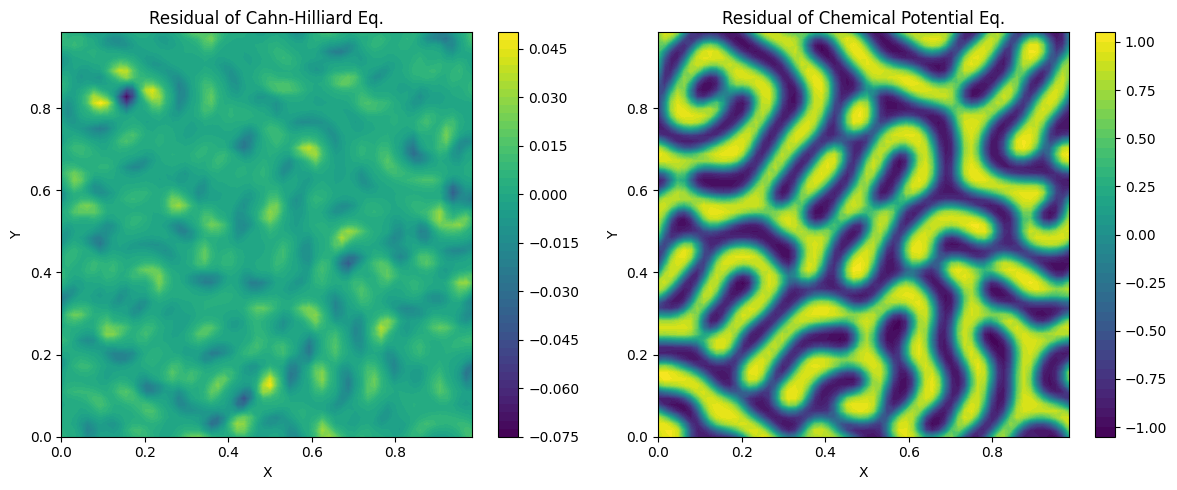

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
im = ax.contourf(meshx, meshy, residual, levels=50, cmap='viridis')
ax.set_title('Residual of Cahn-Hilliard Eq.')
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.colorbar(im, ax=ax)

ax = axes[1]
im = ax.contourf(meshx, meshy, c, levels=50, cmap='viridis')
ax.set_title('Residual of Chemical Potential Eq.')
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.colorbar(im, ax=ax)
fig.tight_layout()

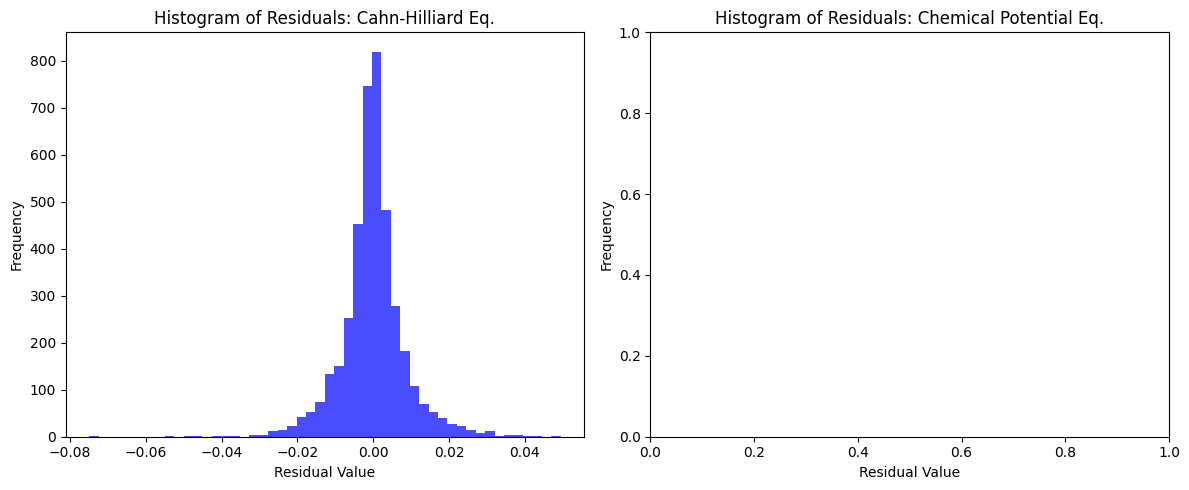

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.hist(residual.flatten(), bins=50, color='blue', alpha=0.7)
ax.set_title('Histogram of Residuals: Cahn-Hilliard Eq.')
ax.set_xlabel('Residual Value')
ax.set_ylabel('Frequency')

ax = axes[1]
# ax.hist(residual2.flatten(), bins=50, color='green', alpha=0.7)
ax.set_title('Histogram of Residuals: Chemical Potential Eq.')
ax.set_xlabel('Residual Value')
ax.set_ylabel('Frequency')
fig.tight_layout()

Mass Min: -4.263256e-14
Mass Max: 5.329071e-15
Mass Fluctuation (Max-Min): 4.796163e-14


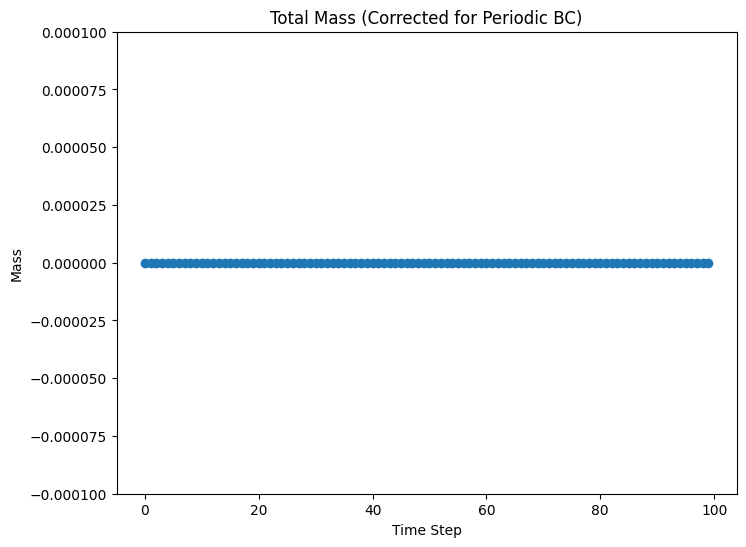

In [28]:

cs_inner = Xs[0:100, 0,] 

# 2. 计算质量
mass = np.sum(cs_inner, axis=(-1, -2))

# 3. 打印统计信息
print(f"Mass Min: {mass.min():.6e}")
print(f"Mass Max: {mass.max():.6e}")
print(f"Mass Fluctuation (Max-Min): {mass.max() - mass.min():.6e}")

# 4. 绘图
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(mass, marker='o')
# 限制 y 轴范围以便看清是否是机器误差级别的波动
mean_mass = mass.mean()
ax.set_ylim(mean_mass - 1e-4, mean_mass + 1e-4) 
ax.set_title('Total Mass (Corrected for Periodic BC)')
ax.set_xlabel('Time Step')
ax.set_ylabel('Mass')
plt.show()

验证自由能递减

$$
F = \int_\Omega \left(
    \frac{\epsilon^2}{2}\lvert\nabla \phi\rvert^2 + \frac{1}{4}(\phi^2-1)^2
\right)\,\mathrm{d}x
$$

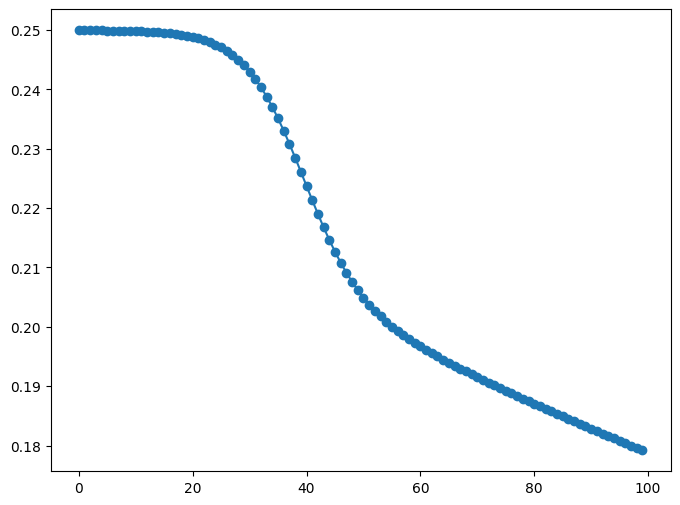

In [40]:
Xs = Xs.astype(jnp.float64)
Ys = Ys.astype(jnp.float64)
times = times.astype(jnp.float64)

x0 = Xs[5]
c0 = x0[0, :, :]

pred = Ys[5]
c = pred[0, :, :]

# 重新获取原始 dt
dt = times[1] - times[0]

# 计算自由能递减
# F = \int_\Omega \left(
#     \frac{\epsilon^2}{2}\lvert\nabla \phi\rvert^2 + \frac{1}{4}(\phi^2-1)^2
# \right)\,\mathrm{d}x



nx = mesh.shape[2]
ny = mesh.shape[1]
lx = 1.0
ly = 1.0
kx = 2 * jnp.pi * jnp.fft.fftfreq(nx, d=lx/nx)
ky = 2 * jnp.pi * jnp.fft.fftfreq(ny, d=ly/ny)
KX, KY = jnp.meshgrid(kx, ky, indexing='xy') # indexing='xy' 对应 (ny, nx) 形状
K2 = KX**2 + KY**2
K4 = K2**2

def compute_F(c):

    grad_c_x_hat = 1j * KX * jnp.fft.fft2(c)
    grad_c_y_hat = 1j * KY * jnp.fft.fft2(c)
    grad_c_x = jnp.fft.ifft2(grad_c_x_hat).real
    grad_c_y = jnp.fft.ifft2(grad_c_y_hat).real
    grad_c_sq = grad_c_x**2 + grad_c_y**2
    f_c = (configs.lambda_param / 2) * grad_c_sq + (1/4) * (c**2 - 1)**2
    F_c = jnp.sum(f_c) * (dx * dy)
    return F_c

cs = Xs[0:100, 0, :, :]
Fs = jax.vmap(compute_F)(cs)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(Fs, marker='o')